# Control voltages 

This is an example of using the control voltages subpackage of freegsnke. This subpackage is designed to implement voltage controls of the tokamak in a way that is similar/based on the MAST-U Plasma Control System (PCS)

The code currently computes the feedback voltages for shape control via virtual circuits This notebook demonstrates using and testing the scheduler and control voltages modules. 

The Scheduler module contains a class that describes and computes the shape control targets throughout a shot simulation. We'll mostly use the word target(s) to refer to the shape control target(s). 

The control voltage module contains a class which is used to perform the computations of feedback voltages via virtual circuits. An instance of the scheduler class is passed to the control_voltages class, which computes the voltages required to achieve the targets specified by the scheduler.    

### Running the notebook

To run the notebook, you will need to have installed the freegsnke package, and also freegsnke-emu (necessary to use NN emulators for computing VC's). 


First we need to import the necessary modules, and set the machine configuration paths.

In [2]:
### IMPORTS ###
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time 
import os 
import pickle 


%load_ext autoreload
%autoreload 2


## set machine config paths 

os.environ["ACTIVE_COILS_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_active_coils.pickle"
)
os.environ["PASSIVE_COILS_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_passive_coils.pickle"
)
os.environ["WALL_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_wall.pickle"
)
os.environ["LIMITER_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_limiter.pickle"
)

# freesgnke imports (after env variables set)
from freegsnke import machine_config
from freegsnke import virtual_circuits as vc
from freegsnke.nonlinear_solve import nl_solver

from freegs4e.plotting import plotEquilibrium as plot_eqi



## creating and saving some VC's 
First we need some example equilibria and vc's for these. We need an equilibrium object and a profiles object, and also a non linear solver object which we'll initilaise now. We'll save a list of a few example equilibria that were created for emulator training/testing. 

On these equilibria we'll compute virtual circuits using freegsnke and save them to a file.

In [3]:
from freegs4e.gradshafranov import mu0  # permeability
from freegsnke import GSstaticsolver, build_machine, equilibrium_update, jtor_update
from freegsnke import virtual_circuits as vc
from freegsnke.jtor_update import Lao85

from copy import deepcopy


def create_equilibrium(plasma_psi=None) -> tuple:

    tokamak = build_machine.tokamak()

    eq = equilibrium_update.Equilibrium(
        tokamak=tokamak,  # provide tokamak object
        Rmin=0.1,
        Rmax=2.0,  # radial range
        Zmin=-2.2,
        Zmax=2.2,  # vertical range
        nx=129,  # number of grid points in the radial direction (needs to be of the form (2**n + 1) with n being an integer)
        ny=129,  # number of grid points in the vertical direction (needs to be of the form (2**n + 1) with n being an integer)
        # psi=plasma_psi
    )

    alpha = np.array([1, 0, -1])
    beta = (1 - 0.3) / 0.3 * alpha * mu0

    profiles = Lao85(
        eq=eq,
        limiter=tokamak.limiter,
        Ip=6e5,
        fvac=0.5,
        alpha=alpha,
        beta=beta,
        alpha_logic=False,
        beta_logic=False,
        Ip_logic=True,
    )

    # Define solver
    GSStaticSolver = GSstaticsolver.NKGSsolver(eq)

    return eq, profiles, GSStaticSolver


# base equi and profiles and solver - contains machine informatoin and greens functions
eq_base, profiles_base, solver = create_equilibrium()
GSStaticSolver = GSstaticsolver.NKGSsolver(eq_base)

eq = deepcopy(eq_base)
profiles = deepcopy(profiles_base)

No probe configuration is provided


Now load some example equilibrium data, and solve for some equilibria. Save in a list of eqi's.

In [7]:
data = pd.read_csv(
    "/Users/alasdair.ross/Documents/HARTREE/Papers/emu_ieee/Nico_comparison/filtered_fgs_3sig_fgs.csv"
)
data = data.iloc[:10]

full_coil_list = list(eq.tokamak.getCurrents().keys())[:12]
data_currents = (
    data.loc[
        :,
        [
            "input/Solenoid",
            "input/px",
            "input/d1",
            "input/d2",
            "input/d3",
            "input/dp",
            "input/d5",
            "input/d6",
            "input/d7",
            "input/p4",
            "input/p5",
            "input/p6",
        ],
    ]
).to_numpy()
data_profiles = (
    data.loc[
        :,
        [
            "input/Ip",
            "input/alpha0",
            "input/alpha1",
            "input/beta0",
            "input/beta1",
            "input/fvac",
        ],
    ]
).to_numpy()
data_targets = (
    data.loc[
        :,
        [
            "target/Rin",
            "target/Rout",
            "target/Rxd",
            "target/Zxd",
            "target/strike_mid_X",
        ],
    ]
).to_numpy()


def load_from_table(index, eq=eq, psi0=None):

    if psi0 is not None:
        eq.plasma_psi = 1.0 * psi0

    for i, coil in enumerate(full_coil_list):
        eq.tokamak[coil].current = data_currents[index, i]

    profiles = Lao85(
        eq=eq,
        limiter=eq.tokamak.limiter,
        Ip=data_profiles[index, 0],
        fvac=data_profiles[index, -1],
        alpha=data_profiles[index, 1:3],
        beta=data_profiles[index, 3:5],
        alpha_logic=True,
        beta_logic=True,
        Ip_logic=True,
    )

    # call the solver
    GSStaticSolver.forward_solve(
        eq=eq,
        profiles=profiles,
        target_relative_tolerance=1e-9,
        verbose=False,  # print output
    )

    return eq, profiles

In [8]:
eq1, prof1 = load_from_table(1)
eq1.tokamak.getCurrents()
# non linear solver
stepper = nl_solver(
    profiles=prof1,
    eq=eq1,
    mode_removal=False,
    linearize=False,
)

Input 'max_mode_frequency' corresponds to 16 independent passive structure normal modes (in addition to the 12 active coils).
The solver's timestep has been set to 0.0001 as explicitly requested. Please compare this with the linear growth rate and reset if necessary.


In [5]:
eq2, prof2 = load_from_table(2)
eq2.tokamak.getCurrents()

{'Solenoid': -10245.623167176578,
 'px': 2168.885371406908,
 'd1': 4369.495777038403,
 'd2': 4752.478174146894,
 'd3': -1993.0806394562203,
 'dp': -4118.006975774822,
 'd5': -1215.834290327909,
 'd6': -636.2911118351494,
 'd7': 970.9969848050296,
 'p4': -3455.789354437843,
 'p5': -5448.422984012786,
 'p6': -67.45229426563992,
 'vessel_1': 0,
 'vessel_2': 0,
 'vessel_3': 0,
 'vessel_4': 0,
 'vessel_5': 0,
 'vessel_6': 0,
 'vessel_7': 0,
 'vessel_8': 0,
 'vessel_9': 0,
 'vessel_10': 0,
 'vessel_11': 0,
 'vessel_12': 0,
 'vessel_13': 0,
 'vessel_14': 0,
 'vessel_15': 0,
 'vessel_16': 0,
 'vessel_17': 0,
 'vessel_18': 0,
 'vessel_19': 0,
 'vessel_20': 0,
 'vessel_21': 0,
 'vessel_22': 0,
 'centrecolumn_1': 0,
 'centrecolumn_2': 0,
 'centrecolumn_3': 0,
 'centrecolumn_4': 0,
 'centrecolumn_5': 0,
 'centrecolumn_6': 0,
 'centrecolumn_7': 0,
 'centrecolumn_8': 0,
 'centrecolumn_9': 0,
 'centrecolumn_10': 0,
 'd1_support_upper_1': 0,
 'd1_support_upper_2': 0,
 'd1_support_upper_3': 0,
 'd1_sup

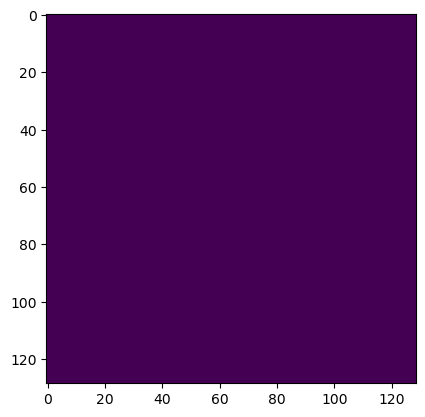

In [6]:
plt.imshow(eq1.plasma_psi - eq2.plasma_psi)

No probe configuration is provided


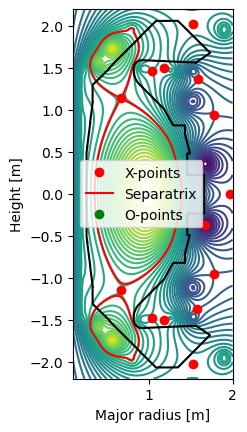

{'Solenoid': 12624.477504672555, 'px': 1183.9298511766228, 'd1': 5860.851104482124, 'd2': 7996.736914503437, 'd3': 838.4055850620789, 'dp': -1189.8487705585858, 'd5': 853.957203171034, 'd6': 945.4224120512343, 'd7': -1264.6134809723494, 'p4': -2217.41088993668, 'p5': -4137.638636890551, 'p6': -91.62990533866788, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd1_support_lower_2': 0, 'd1_sup

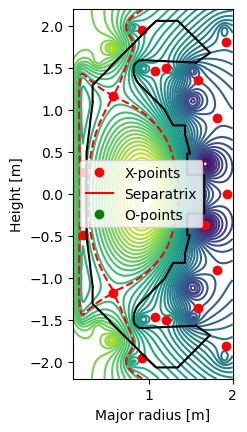

{'Solenoid': -16369.306005659346, 'px': -615.8323717065377, 'd1': 2165.9385136250767, 'd2': 5043.7937611823145, 'd3': -2636.4431647207584, 'dp': -2734.131642791168, 'd5': -691.4166250430735, 'd6': 1123.5526903119844, 'd7': -1918.272537157744, 'p4': -3443.6952459486047, 'p5': -5630.655725512576, 'p6': -30.47212778947141, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd1_support_lower_2': 0,

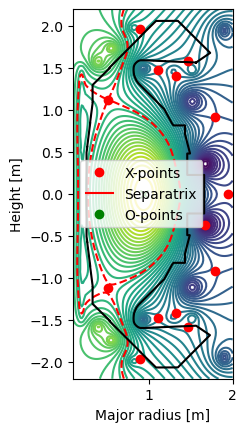

{'Solenoid': -10245.623167176578, 'px': 2168.885371406908, 'd1': 4369.495777038403, 'd2': 4752.478174146894, 'd3': -1993.0806394562203, 'dp': -4118.006975774822, 'd5': -1215.834290327909, 'd6': -636.2911118351494, 'd7': 970.9969848050296, 'p4': -3455.789354437843, 'p5': -5448.422984012786, 'p6': -67.45229426563992, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd1_support_lower_2': 0, 'd1_

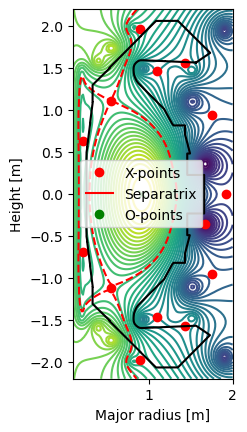

{'Solenoid': -15521.061278574336, 'px': 2016.2630220011315, 'd1': 3973.776334855837, 'd2': 4942.28070509305, 'd3': -2087.3755132032184, 'dp': -3771.631106105988, 'd5': -2018.3430809946824, 'd6': -446.8049220349658, 'd7': 1202.4723264410804, 'p4': -3388.909018187745, 'p5': -5610.990504739633, 'p6': -47.29386867855885, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd1_support_lower_2': 0, 'd

In [7]:
# base equi and profiles and solver - contains machine informatoin and greens functions
eq, profiles, solver = create_equilibrium()
GSStaticSolver = GSstaticsolver.NKGSsolver(eq)

eqi_list = []
profiles_list = []
n_equi = 4
for i in range(n_equi):
    eq = deepcopy(eq_base)
    eq, profiles = load_from_table(i, eq=eq)
    eqi_list.append(eq)
    profiles_list.append(profiles)


for j in range(n_equi):
    plot_eqi(eqi_list[j], show=True)
    print(eqi_list[j].tokamak.getCurrents())

# plot_eqi(eqi_list[3], show=True)
# print(eqi_list[3].tokamak.getCurrents())

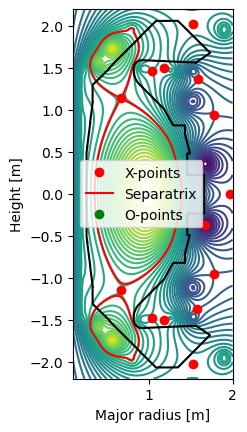

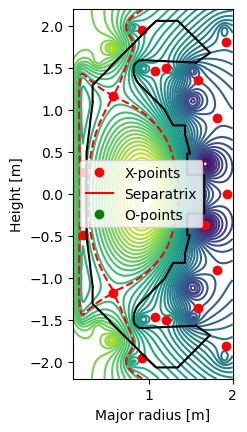

<Axes: xlabel='Major radius [m]', ylabel='Height [m]'>

In [8]:
plot_eqi(eqi_list[0])
plot_eqi(eqi_list[1])

### creating VC sequence 

With this set of equilibria we can compute the VC's and save their info in a pickle file. 

This is saved in a nested dictionary with keys being the times at which to stop using a vc and then the subdictionary containing the vc data (coils, targets, vc matrix, sensitivty matrix, target values). 

This is loaded into a VC sequencer object, which is initialised inside the Targetscheduler object later. The VC sequencer can either be created from a pickle file, or by passing a path to a set of NN emulators. There is an optional flag called 'vc_flag' which is set to be either 'file' or 'emulator'. When set to 'file' the pickle file is loaded, when set to 'emulator' the NN emulators are loaded into a VC_generator object which is part of freegsnke-emu.

Here we create a sequence of VC's and save the pickle file for later use.

Note that here i've given a list of currents that is not the full set of active coils in mast u and also not the standard ordering. This is to demonstrate robustness of the voltage control class




doing equilibrium 0 from list
{'Solenoid': 12624.477504672555, 'px': 1183.9298511766228, 'd1': 5860.851104482124, 'd2': 7996.736914503437, 'd3': 838.4055850620789, 'dp': -1189.8487705585858, 'd5': 853.957203171034, 'd6': 945.4224120512343, 'd7': -1264.6134809723494, 'p4': -2217.41088993668, 'p5': -4137.638636890551, 'p6': -91.62990533866788, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd

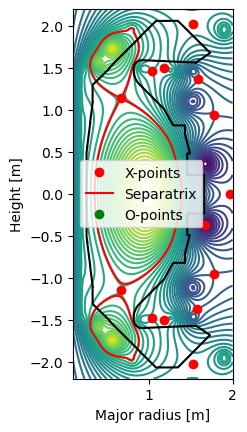

Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_optio

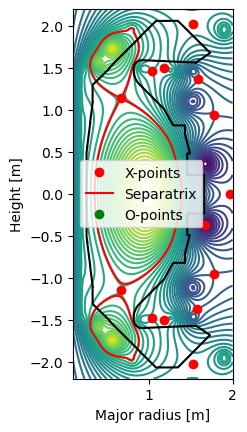

{'Solenoid': 12624.477504672555, 'px': 1183.9298511766228, 'd1': 5860.851104482124, 'd2': 7996.736914503437, 'd3': 838.4055850620789, 'dp': -1189.8487705585858, 'd5': 853.957203171034, 'd6': 945.4224120512343, 'd7': -1264.6134809723494, 'p4': -2217.41088993668, 'p5': -4137.638636890551, 'p6': -91.62990533866788, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd1_support_lower_2': 0, 'd1_sup

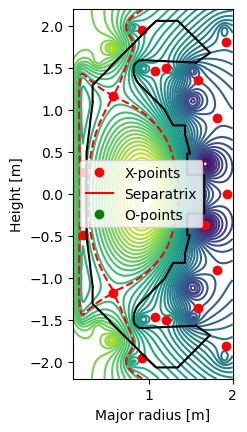

Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_optio

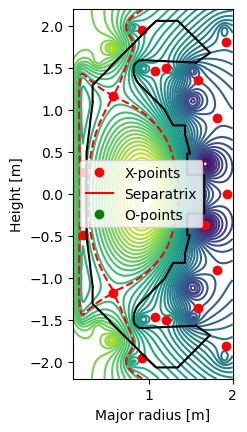

{'Solenoid': -16369.306005659346, 'px': -615.8323717065377, 'd1': 2165.9385136250767, 'd2': 5043.7937611823145, 'd3': -2636.4431647207584, 'dp': -2734.131642791168, 'd5': -691.4166250430735, 'd6': 1123.5526903119844, 'd7': -1918.272537157744, 'p4': -3443.6952459486047, 'p5': -5630.655725512576, 'p6': -30.47212778947141, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd1_support_lower_2': 0,

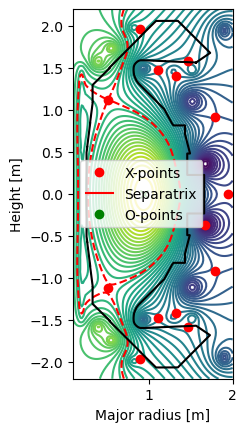

Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_optio

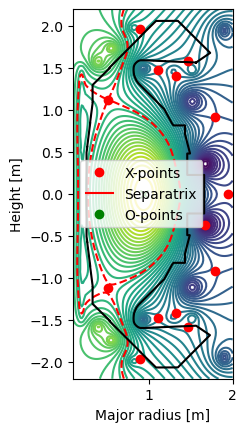

{'Solenoid': -10245.623167176578, 'px': 2168.885371406908, 'd1': 4369.495777038403, 'd2': 4752.478174146894, 'd3': -1993.0806394562203, 'dp': -4118.006975774822, 'd5': -1215.834290327909, 'd6': -636.2911118351494, 'd7': 970.9969848050296, 'p4': -3455.789354437843, 'p5': -5448.422984012786, 'p6': -67.45229426563992, 'vessel_1': 0, 'vessel_2': 0, 'vessel_3': 0, 'vessel_4': 0, 'vessel_5': 0, 'vessel_6': 0, 'vessel_7': 0, 'vessel_8': 0, 'vessel_9': 0, 'vessel_10': 0, 'vessel_11': 0, 'vessel_12': 0, 'vessel_13': 0, 'vessel_14': 0, 'vessel_15': 0, 'vessel_16': 0, 'vessel_17': 0, 'vessel_18': 0, 'vessel_19': 0, 'vessel_20': 0, 'vessel_21': 0, 'vessel_22': 0, 'centrecolumn_1': 0, 'centrecolumn_2': 0, 'centrecolumn_3': 0, 'centrecolumn_4': 0, 'centrecolumn_5': 0, 'centrecolumn_6': 0, 'centrecolumn_7': 0, 'centrecolumn_8': 0, 'centrecolumn_9': 0, 'centrecolumn_10': 0, 'd1_support_upper_1': 0, 'd1_support_upper_2': 0, 'd1_support_upper_3': 0, 'd1_support_lower_1': 0, 'd1_support_lower_2': 0, 'd1_

In [9]:
def save_vc_sequence(
    equi_list,
    profiles_list,
    coils,
    targets,
    solver,
    save_path="freegsnke/control_loop/control_test_files",
):
    """open shot pickle, solve equis, compute VC, save as hdf5 and pickle"""
    VCH = vc.VirtualCircuitHandling()
    VCH.define_solver(solver, target_relative_tolerance=1e-7)

    # dict to save data to
    big_dict = {}

    timestamp_list = []
    # for i in range(len(equi_list)):
    for i in range(3):
        # for i in [3]:
        try:
            print(f"doing equilibrium {i} from list")
            eq = equi_list[i]
            profiles = profiles_list[i]
            print(eq.tokamak.getCurrents())
            plot_eqi(eq, show=True)

            time_calc = 0.1 * i  # dummy time variable
            time_stop = 0.1 * (i + 1)
            input_currents = np.random.rand(len(equi_list[i].tokamak.getCurrents()))
            input_profile_pars = np.random.rand(5)

            VCH.calculate_VC(
                eq=eq,
                profiles=profiles,
                coils=coils,
                targets=targets,
                targets_options=None,
                # name=f"test_vc_{i}",
            )
            virtual_circuit = VCH.latest_VC  # get the latest VC
            print("plotting equi again")
            plot_eqi(eq, show=True)
            print(eq.tokamak.getCurrents())

            # extract attributes
            shape_mat = virtual_circuit.shape_matrix
            targets_val = virtual_circuit.targets_val
            vc_mat = virtual_circuit.VCs_matrix
            gains_arr = 0.5 * np.ones(len(targets))

            dict_temp = {
                "index": i,
                "shape_matrix": shape_mat,
                "vc_matrix": vc_mat,
                "targets": targets,
                "coils": coils,
                "time_calc": time_calc,
                "time_stop": time_stop,
                "targets_val": targets_val,
                "input_currents": input_currents,
                "input_profile_pars": input_profile_pars,
                "target_gains": gains_arr,
            }

            timestamp_list.append(time)
            big_dict[i] = dict_temp

        except Exception as e:
            print("ISSUE computing VC - moving to next equilibrium")
            print(e)

    # save as pickle
    with open(
        "../freegsnke/control_loop/control_test_files/test_vc_set.pkl", "wb"
    ) as fp:
        pickle.dump(big_dict, fp)
        print("vc's saved to pickle")

    return big_dict


# test
targets = ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"]
coils = ["px", "d1", "d2", "d3", "dp", "p4", "p5", "p6"]
VC_dict = save_vc_sequence(
    equi_list=eqi_list,
    profiles_list=profiles_list,
    coils=coils,
    targets=targets,
    solver=solver,
)

### Targets - Schedule and sequence

Now we'll save pickle files that contain the shape target schedule and target sequence. The Schedule refers to which targets will want to be controlled at a given time. This is provided by the user, and should take the format of a dictionary with keys as the time and values as the list of targets to be controlled after that time.

The sequence refers to the desired target values at a given time, again this is provided by the user, and should take the format of a nested dictionary with keys as the shape targets and then the sub dictionary containing times and values at those times. 

These, along with a VC schedule (shedule taking the same meaning as above), are loaded into the target_sequence class by providing the path to the pickle files. 


In [12]:
## Build example target schedule, target sequence.

# saving to pickle

target_seq_dict = {
    "R_in": {"times": [0.1, 0.2, 0.3, 0.4, 0.5], "vals": [0.1, 0.2, 0.2, 0.4, 0.3]},
    "R_out": {"times": [0.1, 0.25, 0.35, 0.55], "vals": [1, 0.99, 0.98, 0.0]},
    "Rx_lower": {"times": [0.1, 0.4, 0.5], "vals": [1, 1.2, 0.9]},
    "Rs_lower_outer": {"times": [0.1, 0.4, 0.6], "vals": [1, 1.2, 0.9]},
}

pickle.dump(
    target_seq_dict,
    open("../freegsnke/control_loop/control_test_files/target_waveform.pkl", "wb"),
)

target_schedule_dict = {
    0.1: ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"],
    0.15: ["R_in"],
    0.25: ["R_out", "Rx_lower", "Rs_lower_outer"],
    0.35: ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"],
    0.3: ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"],
    0.4: ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"],
    0.5: ["R_in", "R_out"],
    0.2: ["R_in", "R_out"],
}

pickle.dump(
    target_schedule_dict,
    open("../freegsnke/control_loop/control_test_files/target_schedule.pkl", "wb"),
)

## Testing Voltage control class code 
We'll start by computing a set of voltages for a given equilibrium and profile object, without passing in a VC object. If no VC object is passed in, the class will build one using the VC class in freegsnke. 
Then we'll test this by giving different sets of targets and currents, again with no input VC object.
Finally we'll load a sequence of VC objects from a pickle file, and use them to obtain voltages.

SETUP 
- import the scheduler and control_voltages modules, 
- import the scheduler module, and set up a scheduler object with target schedule, targe sequence and VC schedule. The VC scheduler c

TESTING
- create an instance of the TargetSequencer class, with paths provided to pickle files with VC's, target sequence and target schedule.
- create an instance of the ShapeController class. We instantiate this with an equilibrium, set of profiles, and a stepping object, and also the target sequencer above. There are options to define the coils to use in the control.
- calculate the voltages using the calculate_feedback_voltage_vector function. This returns a tuple of voltages for the active coils.

In [15]:
import freegsnke.control_loop.shape_targets_control as cv
import freegsnke.control_loop.target_scheduler as target_scheduler
import freegsnke.control_loop.vc_scheduler as vc_scheduler


# choose example eqi from lst - just needed to provide machine info for nl_solver
eq_1 = eqi_list[0]
profiles_1 = profiles_list[0]

# non linear solver
stepper = nl_solver(
    profiles=profiles_1,
    eq=eq_1,
    mode_removal=False,
    linearize=False,
)

Input 'max_mode_frequency' corresponds to 16 independent passive structure normal modes (in addition to the 12 active coils).
The solver's timestep has been set to 0.0001 as explicitly requested. Please compare this with the linear growth rate and reset if necessary.


In [ ]:
plot_eqi(eq_1)

We can first demonstrate the use of the VC sequcener, although in most cases this will only be used within the TargetSequencer class.

In [ ]:
vc_sequence = vc_scheduler.VirtualCircuitScheduler(
    "/Users/alasdair.ross/Documents/HARTREE/freegsnke/examples/test_saves/test_vc_set.pkl"
)

# pick equilibrium
index = 1
eq = eqi_list[index]
profiles = profiles_list[index]


# pick corresponding VC
VC = vc_sequence.retrieve_vc(time_stamp=index * 0.5)
print(VC.targets)
# get target values from VC
targ_values = VC.targets_val
targs_req = targ_values * 1.002

print("target shifts we want will be ", targs_req - targ_values)

Now let's look at the TargetSequencer class. We'll initialize it with target schedule and sequence and for now a set of VC's from file. Using the emulators VC's will be demonstrated later.

When we load the pickles into the TargetSequencer, there are some preliminary compatibility checks that are done to make sure that the target schedule and sequence are compatible with the VC's. If they are not, an error is raised. 

In [ ]:
plot_eqi(
    eq=eq,
)

In [16]:
TS = vc_scheduler.ShapeTargetScheduler(
    target_waveform_path="../freegsnke/control_loop/control_test_files/target_waveform.pkl",
    target_schedule_path="../freegsnke/control_loop/control_test_files/target_schedule.pkl",
    vc_flag="file",
    vc_schedule_path="../freegsnke/control_loop/control_test_files/test_vc_set.pkl",
)

loading ../freegsnke/control_loop/control_test_files/target_schedule.pkl
target schedule times [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]
target schedule dict {0.1: ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer'], 0.15: ['R_in'], 0.25: ['R_out', 'Rx_lower', 'Rs_lower_outer'], 0.35: ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer'], 0.3: ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer'], 0.4: ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer'], 0.5: ['R_in', 'R_out'], 0.2: ['R_in', 'R_out']}
loading ../freegsnke/control_loop/control_test_files/target_waveform.pkl
loading vcs from file
loading VC's from pickle file
there are 3 VC's loaded
checking target schedule and vc sequence
checking compatibility of target schedule and vc sequence at time 0.1
checking compatibility of target schedule and vc sequence at time 0.125
checking compatibility of target schedule and vc sequence at time 0.175
targets requested and vc available targets do not match : vc's will be recomputed as necessary
controlled t

Now we can initialise an instance of the control voltage class and use it to compute feedback control voltages according to the target scheduler. 

We iniitalise the control voltage class with an eq, profile and stepping object. These are there to provide the necessary information to compute equi in freegsnke. It also takes a target scheduler object which we created earlier. 

The main function of the control voltage class is the feedback_voltage_control_timefunc function. This function takes the time of interest, and the current state of the system in the form of an eq and profiles, and a vector of control voltages. 

In [17]:
# Control Voltages Handling
CVH = cv.ShapeController(eq, profiles, stepping=stepper, feedback_target_scheduler=TS)
CVH.feedback_current_rate_timefunc(time_stamp=0.125, eq=eq, profiles=profiles)

number active coils 12
['Solenoid', 'px', 'd1', 'd2', 'd3', 'dp', 'd5', 'd6', 'd7', 'p4', 'p5', 'p6']
['d1', 'd2', 'd3', 'dp', 'd5', 'd6', 'd7', 'p4', 'p5']
initialising with default all active coils
Default targets and current's initialised
all active ['Solenoid', 'px', 'd1', 'd2', 'd3', 'dp', 'd5', 'd6', 'd7', 'p4', 'p5', 'p6']
control coils ['d1', 'd2', 'd3', 'dp', 'd5', 'd6', 'd7', 'p4', 'p5']
target sequencer flag : file
No feedforward scheduler provided. will copy the feedback scheduler
gain matrix [[0.5 0.  0.  0. ]
 [0.  0.5 0.  0. ]
 [0.  0.  0.5 0. ]
 [0.  0.  0.  0.5]]
controlled targets are  ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
loading VC from file
coils being set to default active coils reduced
Virtual circuit provided
targets ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
coils ['px', 'd1', 'd2', 'd3', 'dp', 'p4', 'p5', 'p6']
Observed targets not provided, calculating from equilibrium
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target

array([    0.        , -4590.35266913,   341.95662038,  -810.6561113 ,
       -3522.15447347,  4208.30799346,     0.        ,     0.        ,
           0.        ,  1862.31227655,  -222.09981844,  5520.12116699])

In [ ]:
CVH.inductance_full

In [ ]:
CVH.feedback_current_rate_timefunc(
    time_stamp=0.2,
    eq=eq,
    profiles=profiles,
)

In [ ]:
plot_eqi(eq=eq)

In [ ]:
# testing with provided set of coils
coils_random = ["d1", "d2", "d3", "p5", "p6"]
CVH2 = cv.ShapeController(
    eq, profiles, stepping=stepper, feedback_target_scheduler=TS, coils=coils_random
)
CVH2.feedback_current_rate_timefunc(time_stamp=0.125, eq=eq, profiles=profiles)

In [ ]:
# print("voltages when observed targets are not provided - computed from equi")
# # repeat without providing observed targets
# voltages_vc1a, voltages_vc2a = CVH.calculate_feedback_current_rate_vc_proportional(
#     eq,
#     profiles,
#     virtual_circuit=VC,
#     targets_req=targs_req,
# )

In [ ]:
plot_eqi(eq=eq)

In [ ]:
CVH2.feedback_current_rate_timefunc(time_stamp=0.2, eq=eq, profiles=profiles)

Previously we provided precomputed VC's saved in a pickle file. Here we will use the emulators in freegsnke-emu to compute VC's at run time. To do this we set the 'vc_flag' in the target sequencer to be 'Emulator', and provide a path to a folder containing the trained NN models. 

Initialising the target sequencer object now will load the trained models and precompile the neural network functions so that they run fast when called throughout the simulation. This initialising can take a few seconds, but after it takes orders of 10ms to compute a VC (compared with a few seconds to compute VC via freegsnke)


In [ ]:
t = time.time()
TS_emu = vc_scheduler.ShapeTargetScheduler(
    target_waveform_path="../freegsnke/control_loop/control_test_files/target_waveform.pkl",
    target_schedule_path="../freegsnke/control_loop/control_test_files/target_schedule.pkl",
    vc_flag="Emulator",
    model_path="/Users/alasdair.ross/Documents/HARTREE/freegsnke-emu/experiments/MASTU_ANNfits/24_11_18_cleanedfits_geomtargets_AG",
)
t1 = time.time()
print("time to load emulator target scheduler", t1 - t)
print("-----------\n-----------")
print("building contorl voltages object")
CV_emu = cv.ShapeController(
    eq=eq,
    profiles=profiles,
    stepping=stepper,
    feedback_target_scheduler=TS_emu,
    feedforward_scheduler=TS,
)
t2 = time.time()
print("time to load emulator control voltages object", t2 - t1)

In [ ]:
plot_eqi(eq=eq)

In [ ]:
CV_emu.feedback_current_rate_timefunc(eq=eq, profiles=profiles, time_stamp=0.1)

In [ ]:
CV_emu.feedback_current_rate_timefunc(eq=eq, profiles=profiles, time_stamp=0.4)

plot targets requried as function of time, and plot slopes of targets (dR/dt)_FF

In [ ]:
import matplotlib.pyplot as plt
from pprint import pprint

pprint(TS.target_schedule_dict)
pprint(TS.target_waveform_dict)
fig1, axes = plt.subplots(2, 1, figsize=(10, 10))
ax1 = axes[0]
ax2 = axes[1]

x = np.linspace(0.1, 1, 20)


for key, item in TS.target_waveform_dict.items():
    print(key, item)
    ax1.plot(item["times"], item["vals"], label=key)
    ax1.set_xlim(0, 1)
plt.legend()

y_arr = []
for i in range(len(x)):
    y = TS.feed_forward_gradient(
        x[i], targets=["R_in", "R_out", "Rx_lower", "Rs_lower_outer"]
    )
    y_arr.append(y)

y_arr = np.array(y_arr)

for y in y_arr.transpose():
    print("gradients", y)
    ax2.plot(x, y)
    ax2.set_xlim(0, 1)

## Ip control example 
THis is running pedro's code. 

## Testing Main PCS Pipeline

In [49]:
from freegsnke.control_loop.pcs import main as pcs_main

pcs_main(eq_start=eq, profiles_start=profiles, stepper=stepper)

loading /Users/alasdair.ross/Documents/HARTREE/freegsnke/freegsnke/control_loop/control_test_files/ip_schedule.pkl
target schedule times [0.15, 0.22, 0.31, 0.39, 0.46, 0.56, 0.57, 0.68, 0.73, 0.8]
target schedule dict {0.15: ['Ip'], 0.22: ['Ip'], 0.31: [], 0.39: [], 0.46: ['Ip'], 0.56: ['Ip'], 0.57: ['Ip'], 0.68: ['Ip'], 0.73: [], 0.8: ['Ip']}
loading /Users/alasdair.ross/Documents/HARTREE/freegsnke/freegsnke/control_loop/control_test_files/ip_sequence.pkl
A name for the solenoid is not provided, using 'Solenoid' as label for the solenoid current.
loading /Users/alasdair.ross/Documents/HARTREE/freegsnke/freegsnke/control_loop/control_test_files/ip_control_params.pkl
  The virtual circuit vector: [1.   0.3  0.2  0.1  0.54 0.45 0.13 0.27 0.89 0.17 0.34 0.42]
loading /Users/alasdair.ross/Documents/HARTREE/freegsnke/freegsnke/control_loop/control_test_files/target_schedule.pkl
target schedule times [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]
target schedule dict {0.1: ['R_in', 'R_out', 'Rx

In [24]:
from freegsnke.control_loop.pcs import simulate_shot

test_control_kwargs = {
    "ip_schedule": "../freegsnke/control_loop/control_test_files/ip_schedule.pkl",
    "ip_control_params": "../freegsnke/control_loop/control_test_files/ip_control_params.pkl",
    "ip_waveform": "../freegsnke/control_loop/control_test_files/ip_sequence.pkl",
    "fb_target_waveform": "../freegsnke/control_loop/control_test_files/target_waveform.pkl",
    "fb_target_schedule": "../freegsnke/control_loop/control_test_files/target_schedule.pkl",
    "ff_target_waveform": "../freegsnke/control_loop/control_test_files/target_waveform.pkl",
    "ff_target_schedule": "../freegsnke/control_loop/control_test_files/target_schedule.pkl",
    "vc_schedule": "../freegsnke/control_loop/control_test_files/test_vc_set.pkl",
}
test_config_kwargs = {
    "plasma_resistivity": 0.84,
    "plasma_inductance": 3.9,
    "plas_sol_inductance": 2.7,
    "Rp": 0.84,
    "R_vec": np.random.rand(12),
    "coil_gains": np.diag(np.random.rand(12)),
}

time_slices = np.arange(0.15, 1, 0.1)
print(test_control_kwargs["ip_schedule"])
print(time_slices)

simulate_shot(
    eq,
    profiles,
    stepper=stepper,
    time_slices=time_slices,
    config_kwargs=test_config_kwargs,
    control_kwargs=test_control_kwargs,
)

../freegsnke/control_loop/control_test_files/ip_schedule.pkl
[0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
{'ip_schedule': '../freegsnke/control_loop/control_test_files/ip_schedule.pkl', 'ip_control_params': '../freegsnke/control_loop/control_test_files/ip_control_params.pkl', 'ip_waveform': '../freegsnke/control_loop/control_test_files/ip_sequence.pkl', 'fb_target_waveform': '../freegsnke/control_loop/control_test_files/target_waveform.pkl', 'fb_target_schedule': '../freegsnke/control_loop/control_test_files/target_schedule.pkl', 'ff_target_waveform': '../freegsnke/control_loop/control_test_files/target_waveform.pkl', 'ff_target_schedule': '../freegsnke/control_loop/control_test_files/target_schedule.pkl', 'vc_schedule': '../freegsnke/control_loop/control_test_files/test_vc_set.pkl'}
{'plasma_resistivity': 0.84, 'plasma_inductance': 3.9, 'plas_sol_inductance': 2.7, 'Rp': 0.84, 'R_vec': array([0.82076712, 0.90884372, 0.81552382, 0.15941446, 0.62889844,
       0.39843426, 0.06271295, 0